In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb

In [2]:
df_original = pd.read_csv('Children Recode_final.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 12)

In [3]:
# Columns to scale
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()

# Make copies of training and test sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only selected columns
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [4]:
# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_sm))

Before SMOTE: Counter({0: 1110, 1: 569})
After SMOTE: Counter({0: 1110, 1: 1110})


**XGBoost Model**

In [ ]:
# Compute class imbalance ratio
from collections import Counter
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb.fit(X_train_sm, y_train_sm)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [14]:
# Predict on test set
y_pred = xgb.predict(X_test_scaled)

# Evaluate
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.72      0.50      0.59       371
           1       0.39      0.61      0.47       189

    accuracy                           0.54       560
   macro avg       0.55      0.56      0.53       560
weighted avg       0.61      0.54      0.55       560



**CatBoost Model**

In [24]:
# Train LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',  # LightGBM auto-balancing
    random_state=42
)

lgbm.fit(X_train_sm, y_train_sm)


[LightGBM] [Info] Number of positive: 1110, number of negative: 1110
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 2220, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=6,
               n_estimators=500, random_state=42)

In [26]:

# Predict and Evaluate
y_pred = lgbm.predict(X_test_scaled)

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.69      0.74      0.72       371
           1       0.41      0.35      0.38       189

    accuracy                           0.61       560
   macro avg       0.55      0.55      0.55       560
weighted avg       0.60      0.61      0.60       560



**Feature Importance Plot**

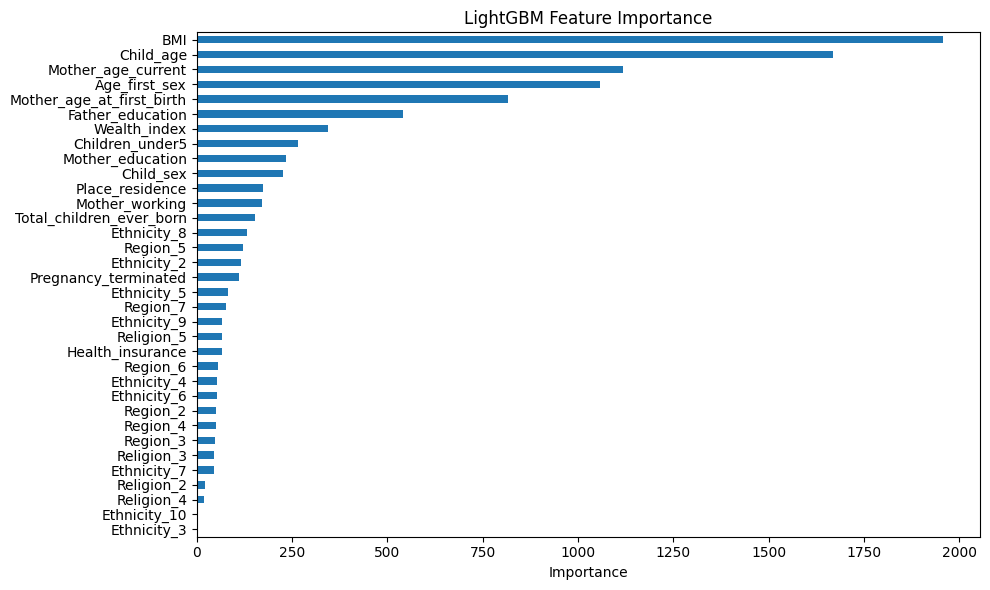

In [29]:
pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
